# CONFIG

In [40]:
import os
import pandas as pd
import numpy as np

from dataclasses import dataclass
from maikol_utils.print_utils import print_separator


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
@dataclass
class Configuration:
    """Configuration dataclass to hold application settings."""
    # =========================
    seed: int = 42

    # =========================
    DATA_PATH: str = os.path.join("data", "WIDER_train", "images")
    
    max_files: int = 100
    gray_scale: bool = True

    # =========================
    crop_size: int = 44
    stride: int = 4
    subsample_factor: float = 0.8
    normalize_window: int = 5


    def __post_init__(self):
        ...


# CODE

## Data

In [42]:
from maikol_utils.file_utils import list_dir_files

CONFIG = Configuration()
rng = np.random.default_rng(CONFIG.seed)

files, n = list_dir_files(CONFIG.DATA_PATH, recursive=True)
print(f"Found {n} files in {CONFIG.DATA_PATH}")

files = rng.choice(files, size=CONFIG.max_files, replace=False)
print(f"Selected {len(files)} files for processing.")


Found 12880 files in data/WIDER_train/images
Selected 100 files for processing.


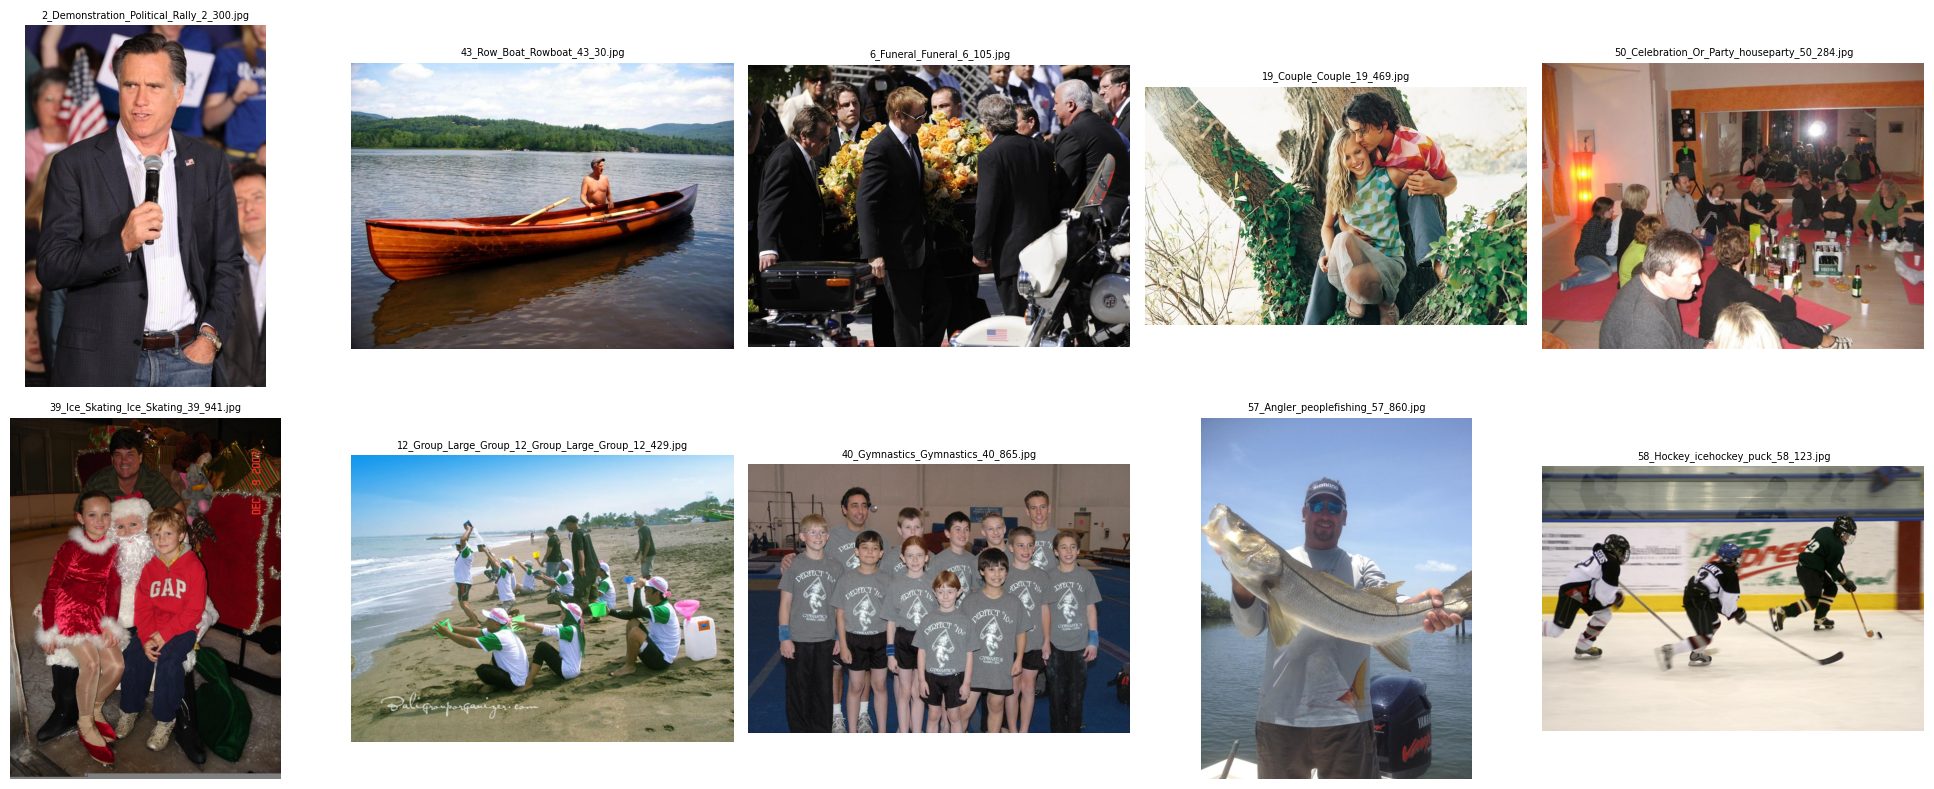

In [43]:
import matplotlib.pyplot as plt
from PIL import Image

rng = np.random.default_rng(CONFIG.seed)
sample = rng.choice(files, size=10, replace=False)

def show_images(images):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, path in zip(axes.flatten(), images):
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(path), fontsize=7)

    plt.tight_layout()
    plt.show()

show_images(sample)


## Get all image crops

In [ ]:
import cv2
from concurrent.futures import ProcessPoolExecutor, as_completed

def get_all_image_crops(CONFIG: Configuration, image_path: str):
    crops = []
    if CONFIG.gray_scale:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(image_path)


    while img.shape[0] > CONFIG.crop_size and img.shape[1] > CONFIG.crop_size:
        crops.extend(get_image_crops(img, CONFIG.stride, CONFIG.crop_size))
        img = cv2.resize(
            img, 
            dsize=(
                int(img.shape[0] * CONFIG.subsample_factor), 
                int(img.shape[1] * CONFIG.subsample_factor)
            ), 
            interpolation=cv2.INTER_AREA
        )
    return crops

def get_image_crops(img: np.ndarray, stride: int, crop_size: int):
    h, w = img.shape[:2]
    crops = []
    for i in range(0, h - crop_size + 1, stride):
        for j in range(0, w - crop_size + 1, stride):
            crops.append(img[
                i:i + crop_size, 
                j:j + crop_size
            ])
    return crops



crops = get_all_image_crops(CONFIG, sample[7])


In [52]:
import time

t1 = time.time()
all_crops_seq = [get_all_image_crops(CONFIG, img) for img in files]
t2 = time.time()
seq_time = t2 - t1

print(f"{seq_time:.2f}s  ({seq_time/len(files)*1000:.1f} ms/img)")

2.08s  (20.8 ms/img)


107697
[ 9255 83346  9611 70490 47263 46632 75103 10142 21697 92464]


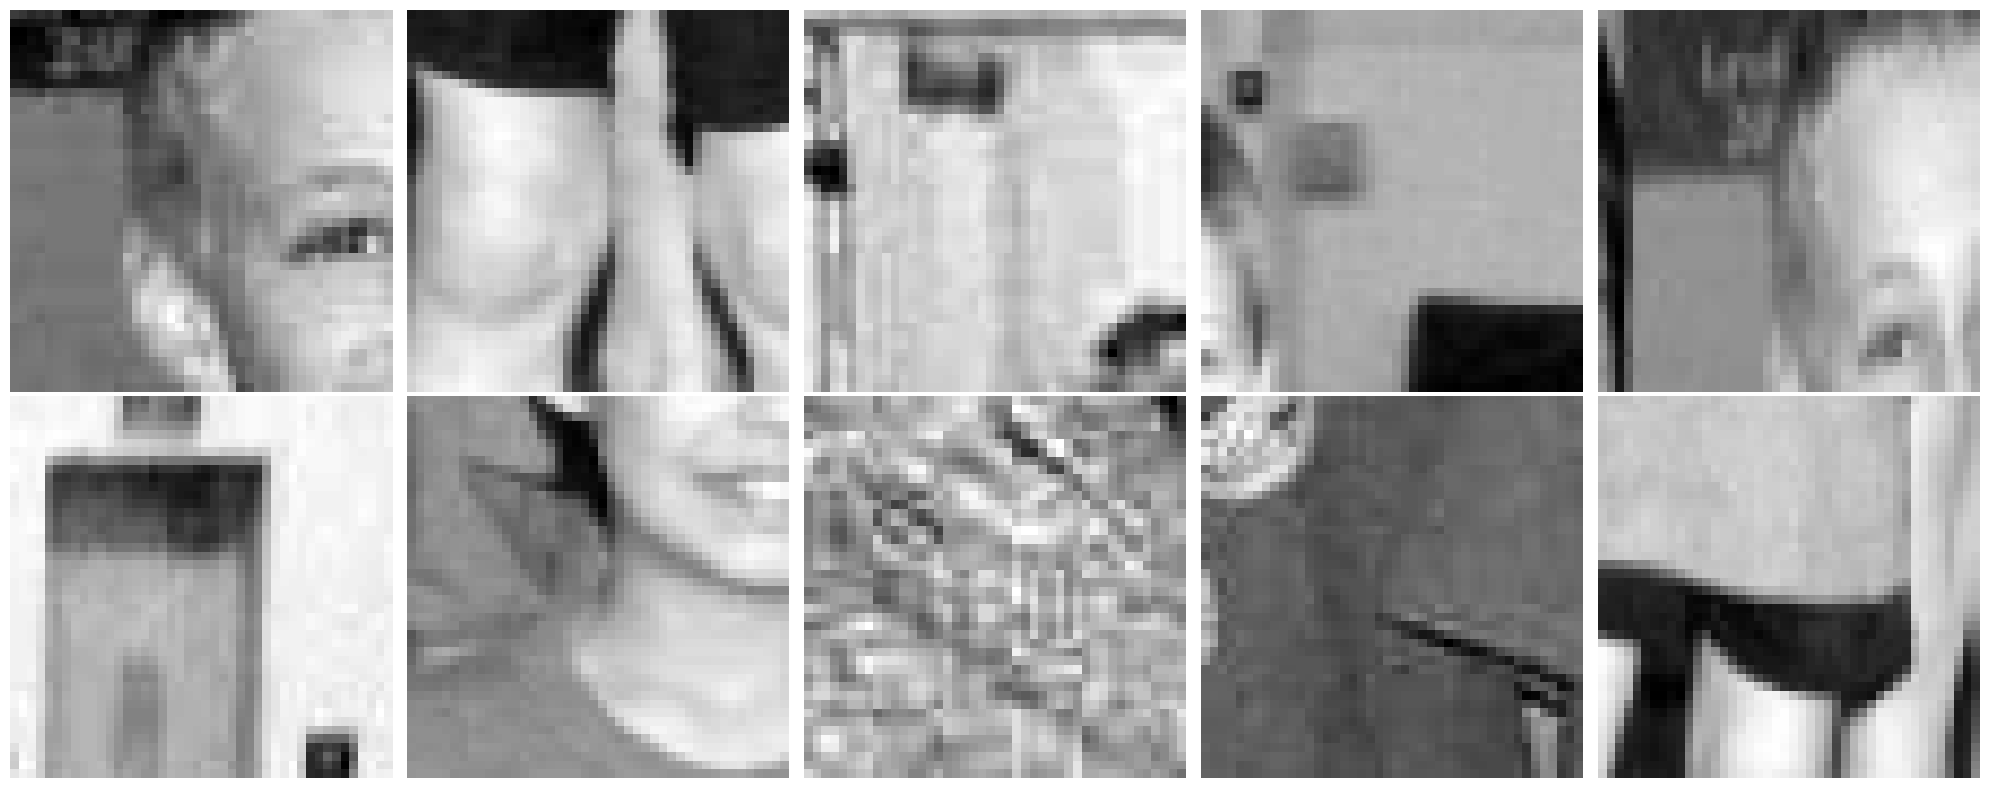

In [54]:
def show_crops(crops_to_show):
    n = len(crops_to_show)
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, crop in zip(axes, crops_to_show):
        # grayscale (2D) — show directly; BGR (3D uint8) — convert to RGB
        if crop.ndim == 2:
            ax.imshow(crop, cmap="gray")
        else:
            crop_show = crop
            if crop.dtype != np.uint8:
                crop_show = np.clip(crop, 0, 255).astype(np.uint8)
            ax.imshow(cv2.cvtColor(crop_show, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    for ax in axes[len(crops_to_show):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


print(len(crops))

rng = np.random.default_rng(CONFIG.seed)
k = min(10, len(crops))
idx = rng.choice(len(crops), size=k, replace=False)
print(idx)
sampled_crops = [crops[i] for i in idx]
show_crops(sampled_crops)


## Normalization

### Integral image

In [ ]:
# def get_integral_image(img: np.ndarray):
#     integral = np.zeros_like(img, dtype=np.uint64) 

#     for i in range(img.shape[0]):
#         for j in range(img.shape[1]):
#             integral[i, j] = img[0:i+1, 0:j+1].sum()

#     return integral

# def get_integral_squared_image(img: np.ndarray):
#     img_2 = np.square(img)
#     integral = np.zeros_like(img_2, dtype=np.uint64) 

#     for i in range(img_2.shape[0]):
#         for j in range(img_2.shape[1]):
#             integral[i, j] = img_2[0:i+1, 0:j+1].sum()

#     return integral

# Versiones rápidas
def get_integral_image(img: np.ndarray) -> np.ndarray:
    return img.astype(np.uint64).cumsum(axis=0).cumsum(axis=1)

def get_integral_squared_image(img: np.ndarray) -> np.ndarray:
    img2 = img.astype(np.uint64) ** 2
    return img2.cumsum(axis=0).cumsum(axis=1)

def get_integral_sum(integral: np.ndarray, x1, y1, x2, y2) -> int:
    A = integral[x1 - 1, y1 - 1] if (x1 > 0 and y1 > 0) else 0
    B = integral[x1 - 1, y2] if x1 > 0 else 0
    C = integral[x2, y1 - 1] if y1 > 0 else 0
    D = integral[x2, y2]
    return D - B - C + A


integral = get_integral_image(crops[1])
integral_2 = get_integral_squared_image(crops[1])
# print(integral)
# print(integral_2)

print(get_integral_sum(integral, 0, 0, 10, 10))
print(get_integral_sum(integral_2, 0, 0, 10, 10))

[[   150    302    458 ...   7292   7488   7686]
 [   302    608    922 ...  14595  14987  15384]
 [   456    919   1393 ...  21964  22553  23150]
 ...
 [  7896  15840  23858 ... 345520 353900 362306]
 [  8093  16234  24449 ... 353988 362573 371184]
 [  8289  16627  25040 ... 362571 371365 380189]]
[[   22500    45604    69940 ...  1270280  1308696  1347900]
 [   45604    92424   141724 ...  2543769  2620601  2699406]
 [   69320   140789   215689 ...  3839600  3955241  4074046]
 ...
 [ 1495900  3008664  4548200 ... 67843160 69515634 71198334]
 [ 1534709  3086282  4664627 ... 69551898 71266397 72991122]
 [ 1573125  3163507  4781056 ... 71308365 73066545 74836639]]
21146
3714878


/tmp/ipykernel_52363/3727172890.py:33: RuntimeWarning: overflow encountered in scalar subtract
  return D - B - C + A
/tmp/ipykernel_52363/3727172890.py:33: RuntimeWarning: overflow encountered in scalar add
  return D - B - C + A


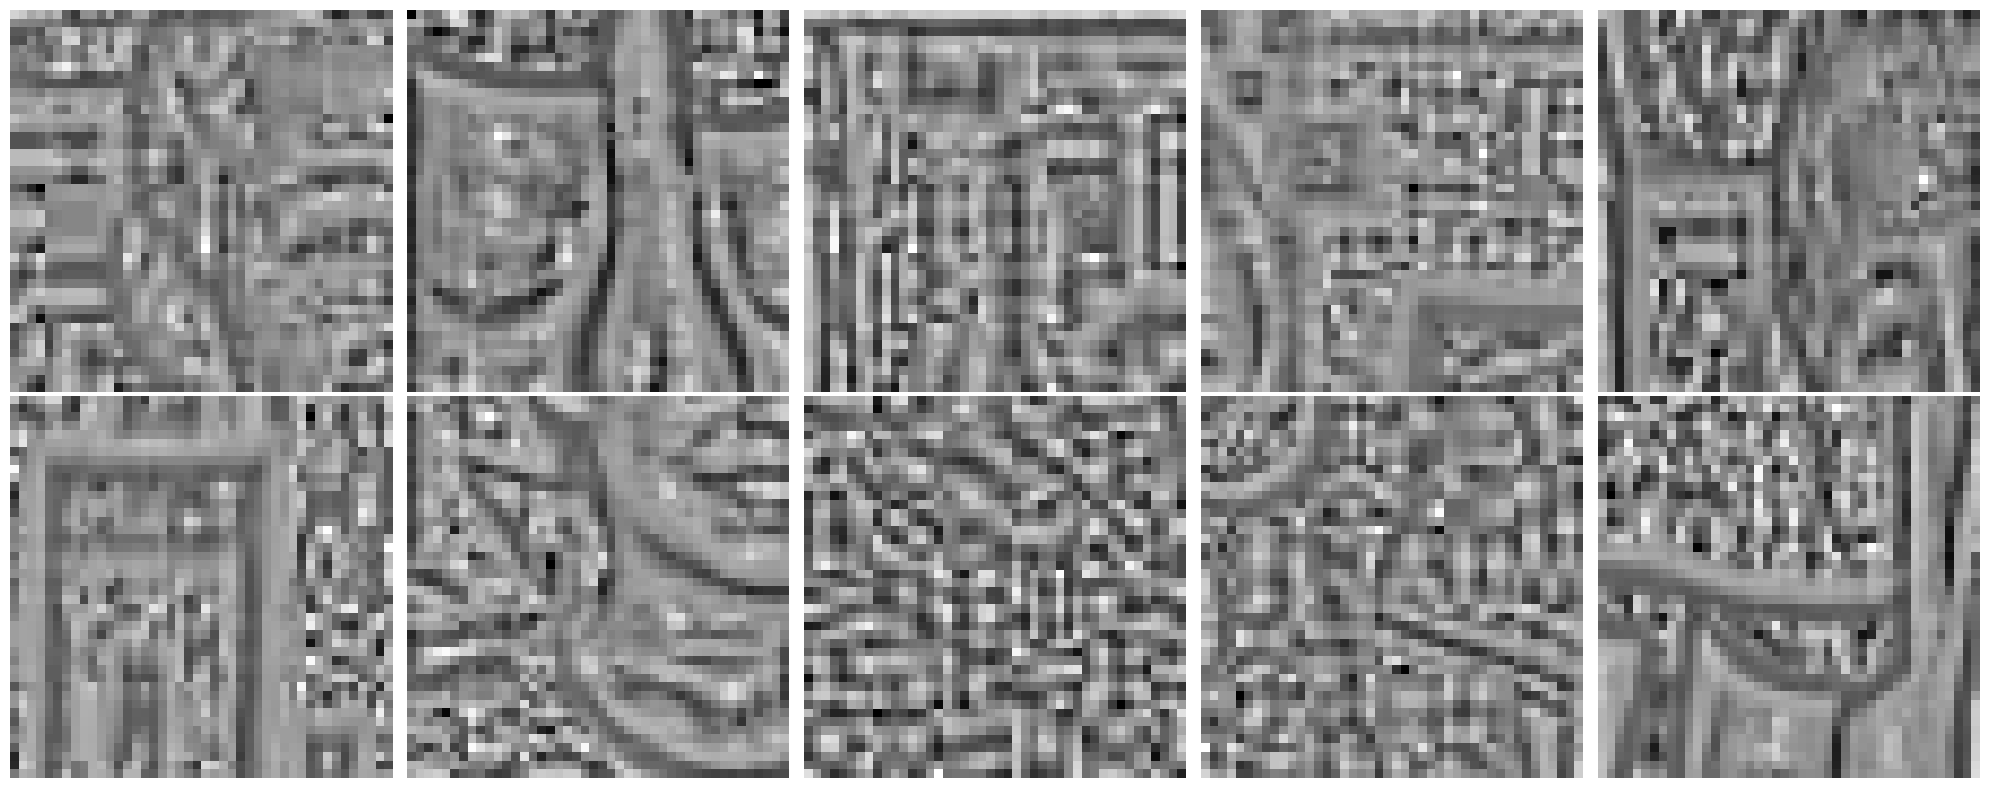

In [55]:
def local_normalize_image(CONFIG: Configuration, img: np.ndarray):
    integral = get_integral_image(img) 
    integral_2 = get_integral_squared_image(img)

    x_idx, y_idx = np.indices(img.shape)
    vect_normalize = np.vectorize(
        local_normalize_pixel,
        excluded=["integral", "integral_2", "win_size"]
    )

    return vect_normalize(
        img,
        integral=integral,
        integral_2=integral_2,
        x=x_idx,
        y=y_idx,
        win_size=CONFIG.normalize_window
    )

def local_normalize_pixel(pixel, integral, integral_2, x, y, win_size):
    win = win_size // 2
    max_row = integral.shape[0] - 1
    max_col = integral.shape[1] - 1

    # Ajustar límites
    r1 = max(0, x - win)
    r2 = min(max_row, x + win)
    c1 = max(0, y - win)
    c2 = min(max_col, y + win)

    pixels = (r2 - r1 + 1) * (c2 - c1 + 1)

    suma = get_integral_sum(integral, r1, c1, r2, c2)
    suma_2 = get_integral_sum(integral_2, r1, c1, r2, c2)
    mu = suma / pixels

    var = max(0.0, (suma_2 - (2*mu*suma) + pixels*mu*mu)/pixels) 
    sig = np.sqrt(var)

    # Prevent division by zero
    if sig < 1e-6:
        return 0.0

    return (pixel - mu)/sig


rng = np.random.default_rng(CONFIG.seed)
k = min(10, len(crops))
idx = rng.choice(len(crops), size=k, replace=False)
sampled_crops = [local_normalize_image(CONFIG, crops[i]) for i in idx]
show_crops(sampled_crops)


/tmp/ipykernel_52363/3727172890.py:33: RuntimeWarning: overflow encountered in scalar subtract
  return D - B - C + A
/tmp/ipykernel_52363/3727172890.py:33: RuntimeWarning: overflow encountered in scalar add
  return D - B - C + A


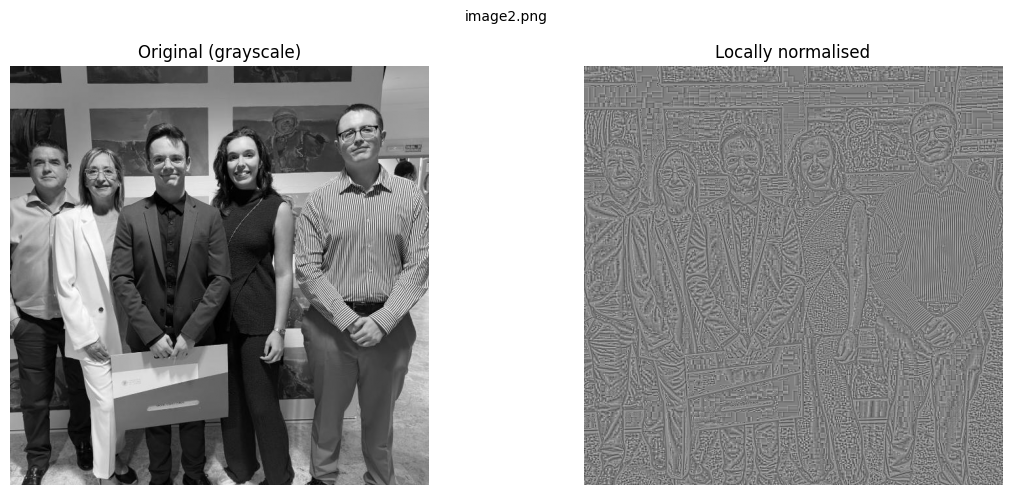

In [58]:

# --- Load image (swap path for any other image) ---
img_path = os.path.join("data", "image2.png")
img_bgr  = cv2.imread(img_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img_norm = local_normalize_image(CONFIG, img_gray)

# --- Plot original vs locally normalised ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")

axes[1].imshow(img_norm, cmap="gray")
axes[1].set_title("Locally normalised")
axes[1].axis("off")

plt.suptitle(os.path.basename(img_path), fontsize=10)
plt.tight_layout()
plt.show()
